# Avance proyecto - Implementacion Shallow NN

## Equipo: 8

## Integrantes:
* Andres Camilo Torres Cajamarca (antorresca@unal.edu.co)
* Adrian Ramirez Gonzalez (adramirez@unal.edu.co)
* Andres Felipe Poveda Bellon (anpovedab@unal.edu.co)
* Jorge Aurelio Morales Manrique (jomorales@unal.edu.co)
* Miguel Angel Pinzon Garcia (mipinzong@unal.edu.co)

# Clasificacion de tumores cerebrales usando una Shallow NN

En este primer avance del proyecto se implementara una red neuronal superficial (Shallow NN) la cual tendra que identificar correctamente la presencia de tumores (o la falta de ellos) en imagenes de resonancias magneticas. La red neuronal tendra que clasificar la imgan en una de las siguientes 4 categorias:

1. Saludable (No hay tumores)
2. Meningioma
3. Tumor pituitario
4. Glioma

# Importacion de las librerias

Se realiza la importacion de las librerias que se usaran a lo largo de la construccion y analisis de la red neuronal superficial.

In [1]:
import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
import sklearn

I0000 00:00:1780334883.019263  124866 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780334883.055221  124866 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780334883.826368  124866 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Preprocesamiento de datos y analisis exploratorio

**Dateset usado:** https://www.kaggle.com/datasets/miadul/brain-tumor-mri-dataset/data  
**Cantidad de imagenes total segun Kaggle:** 7023

Para este caso, el dataset de Kaggle ya viene dividido en 4 carpetas distintas divididas por el tipo de tumor que almacenan. Por esta razon, inicialmente se cargara todo el dataset usando one hot encoding para representar cada categoria.  

Las imagenes seran cargadas con una resolucion de 128x128 para mejorar la velocidad de procesamiento. Ademas, estas imagenes seran cargadas en escala de grises, ya que las imagenes de resonancias magneticas presentan colores que se pueden representar en esta escala sin perder informacion util.  

In [2]:
dataset = keras.utils.image_dataset_from_directory(
    "./brain_tumor_dataset",
    labels="inferred",
    color_mode="grayscale",
    label_mode="categorical",
    batch_size=None,
    image_size=(128, 128),
    seed=5125
)

Found 7023 files belonging to 4 classes.


W0000 00:00:1780334884.820001  124945 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1780334884.864782  124866 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Se verifica que se hayan detectado correctamente las categorias y que la resolucion de todas las imagenes sea de 128x128 (esto tambien permite verificar que la cantidad de imagenes cargadas coincida con las que reporta Kaggle)

In [3]:
print(f"Categorias de las imagenes: {dataset.class_names}")

resolutions = dict()

for image, label in dataset:
    if not image.shape in resolutions:
        resolutions[image.shape] = 1
    else:
        resolutions[image.shape] += 1

print("Resoluciones encontradas:")
for key, value in resolutions.items():
    print(f"\t{key[0]}x{key[1]}. Cantidad: {value}")

Categorias de las imagenes: ['glioma', 'healthy', 'meningioma', 'pituitary']
Resoluciones encontradas:
	128x128. Cantidad: 7023


Se visualizan algunas imagenes al azar para verificar que se vean correctamente

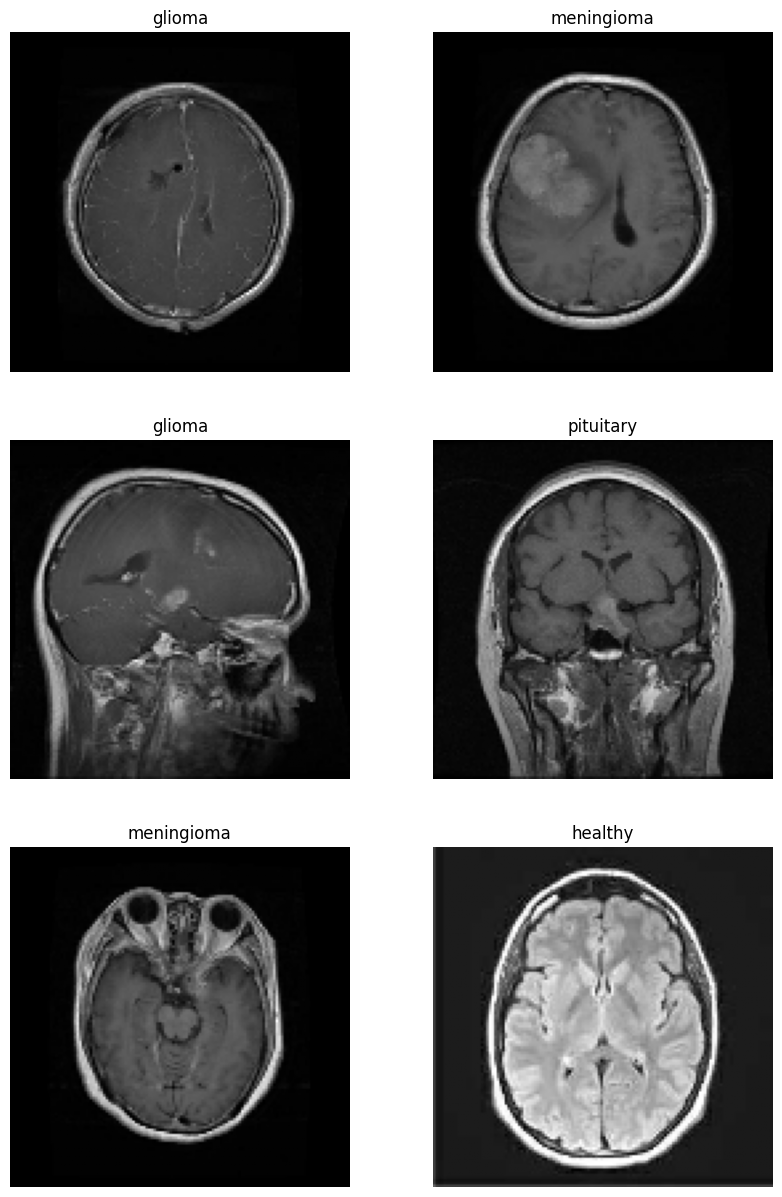

In [4]:
fig, ax = plt.subplots(3, 2, figsize=(10, 15))

row = 0
col = 0
for image, label in dataset.shuffle(buffer_size=dataset.cardinality()).take(6):
    ax[row][col].imshow(image.numpy().squeeze(), cmap="gray")
    ax[row][col].set_title(dataset.class_names[np.argmax(label.numpy())])
    ax[row][col].axis("off")

    col = col + 1

    if col == 2:
        col = 0
        row = row + 1


Se cuenta la cantidad de imagenes de cada categoria para verificar que todas las categorias tengan una cantidad similar de imagenes. En este caso, se puede observar que todas las categorias tienen porcentajes similares de imagenes respecto al total del dataset.

In [5]:
num_glioma = 0
num_healthy = 0
num_meningioma = 0
num_pituitary = 0

for image, label in dataset:
    match np.argmax(label.numpy()):
        case 0:
            num_glioma += 1
        case 1:
            num_healthy += 1
        case 2:
            num_meningioma += 1
        case 3:
            num_pituitary += 1

total = num_glioma + num_healthy + num_meningioma + num_pituitary

print(f"Numero de imagenes de gliomas: {num_glioma}. Porcentaje del total: {np.round((num_glioma/total)*100,2)}%")
print(f"Numero de imagenes saludables: {num_healthy}. Porcentaje del total: {np.round((num_healthy/total)*100,2)}%")
print(f"Numero de imagenes de meningiomas: {num_meningioma}. Porcentaje del total: {np.round((num_meningioma/total)*100,2)}%")
print(f"Numero de imagenes de tumores pituitarios: {num_pituitary}. Porcentaje del total: {np.round((num_pituitary/total)*100,2)}%")

Numero de imagenes de gliomas: 1621. Porcentaje del total: 23.08%
Numero de imagenes saludables: 2000. Porcentaje del total: 28.48%
Numero de imagenes de meningiomas: 1645. Porcentaje del total: 23.42%
Numero de imagenes de tumores pituitarios: 1757. Porcentaje del total: 25.02%


Se grafica una distribucion por clases para ver mejor la cantidad de imagenes por categoria

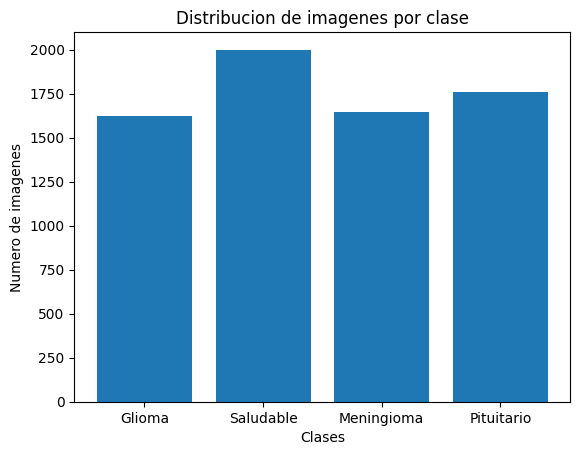

In [6]:
fig, ax = plt.subplots()
ax.bar(["Glioma", "Saludable", "Meningioma", "Pituitario"], [num_glioma, num_healthy, num_meningioma, num_pituitary])

ax.set_title("Distribucion de imagenes por clase")
ax.set_xlabel("Clases")
ax.set_ylabel("Numero de imagenes")
plt.show()

# Extraccion de caracteristicas y division del dataset

Para el proceso de extraccion de caracteristicas (feature extraction), se usara GLCM (Gray Level Co-occurrence Matrices) a partir de la cual se extraeran los siguientes valores:

1. Contraste
2. Disimilaridad
3. Homogeneidad
4. ASM
5. Energia
6. Correlacion

Estos valores se calcularan usando angulo los angulos 0°, 45°, 90° y 135°. Ademas, tambien se define una distancia de 1. En total, se tendra un conjunto de 24 valores que servira como entrada en la red neuronal para cada imagen.

Adicionalmente, en esta seccion tambien se hara la division del dataset en 3 partes: Entrenamiento, validacion y test. Para esta division se utilizaran los siguientes porcentajes:
1. **Entrenamiento:** 80%
2. **Validacion:** 10%
3. **Test:** 10%

In [7]:
def extract_GLCM(image):
    image = np.squeeze(image.numpy()).astype(np.uint8)

    features = []
    glcm = graycomatrix(image, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=256, symmetric=True, normed=True)

    features.extend(graycoprops(glcm, 'contrast').flatten())
    features.extend(graycoprops(glcm, 'dissimilarity').flatten())
    features.extend(graycoprops(glcm, 'homogeneity').flatten())
    features.extend(graycoprops(glcm, 'ASM').flatten())
    features.extend(graycoprops(glcm, 'energy').flatten())
    features.extend(graycoprops(glcm, 'correlation').flatten())

    return features

train_rate = 0.8
validation_rate = 0.1
test_rate = 0.1
total = int(dataset.cardinality())

train_quantity = int(total * train_rate)
validation_quantity = int(total * validation_rate)
test_quantity = int(total * test_rate)

train_data = []
train_results = []

validation_data = []
validation_results = []

test_data = []
test_results = []

counter = 0
for image, label in dataset.shuffle(buffer_size=dataset.cardinality()):
    feature_extraction = extract_GLCM(image)

    if counter < train_quantity:
        train_data.append(feature_extraction)
        train_results.append(label.numpy())

    elif train_quantity <= counter < train_quantity + validation_quantity:
        validation_data.append(feature_extraction)
        validation_results.append(label.numpy())

    elif train_quantity + validation_quantity <= counter < total:
        test_data.append(feature_extraction)
        test_results.append(label.numpy())

    counter += 1

train_data = np.array(train_data)
train_results = np.array(train_results)

validation_data = np.array(validation_data)
validation_results = np.array(validation_results)

test_data = np.array(test_data)
test_results = np.array(test_results)

Se verifica que los datos hayan quedado correctamente divididos

In [8]:
print(f"Cantidad de datos de entrenamiento: {len(train_data)}. Porcentaje: {np.round((len(train_data)/total)*100,2)}%")
print(f"Cantidad de datos de validacion: {len(validation_data)}. Porcentaje: {np.round((len(validation_data)/total)*100,2)}%")
print(f"Cantidad de datos de test: {len(test_data)}. Porcentaje: {np.round((len(test_data)/total)*100,2)}%")

Cantidad de datos de entrenamiento: 5618. Porcentaje: 79.99%
Cantidad de datos de validacion: 702. Porcentaje: 10.0%
Cantidad de datos de test: 703. Porcentaje: 10.01%


# Construccion de la Red neuronal superficial (shallow NN)

La red neuronal se compondra de una capa de entrada, tres capas ocultas y una capa de salida. Estas capas tendran las siguientes caracteristicas:

## Capas
#### Capa de entrada
* Tamaño: 24 valores

#### Capas ocultas

##### Primera capa
* Tipo: Dense
* Tamaño: 100 neuronas
* Funcion de activacion: ReLU

##### Segunda capa
* Tipo: Dropout
* Dropout rate: 0.3

##### Tercera capa
* Tipo: Dense
* Tamaño: 50 neuronas
* Funcion de activacion: ReLU

#### Capa de salida
* Tamaño: 4 neuronas
* Funcion de activacion: Softmax

La red neuronal sera entrenda durante 100 epochs usando la entropia categorica cruzada como funcion de perdida y Adam como optimizador.

In [9]:
model = keras.Sequential(
    [
        keras.Input((train_data.shape[1],)),
        layers.Dense(100, activation="relu", name="hidden_layer_1"),
        layers.Dropout(0.3, name="dropout_layer"),
        layers.Dense(50, activation="relu", name="hidden_layer_2"),
        layers.Dense(4, activation="softmax", name="output_layer"),
    ])

model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"]
)

epochs = 100

train_model = model.fit(
    train_data,
    train_results,
    epochs=epochs,
    validation_data=(validation_data,validation_results)
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 100)            │         2,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 4)              │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,754 (30.29 KB)

 Trainable params: 7,754 (30.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2677 - loss: 27.3741 - val_accuracy: 0.3020 - val_loss: 3.0560
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step - accuracy: 0.2725 - loss: 5.0439 - val_accuracy: 0.3006 - val_loss: 1.3973
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2816 - loss: 1.9936 - val_accuracy: 0.3732 - val_loss: 1.3237
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3076 - loss: 1.5384 - val_accuracy: 0.4501 - val_loss: 1.2859
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3355 - loss: 1.4022 - val_accuracy: 0.4459 - val_loss: 1.2440
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3448 - loss: 1.3291 - val_accuracy: 0.3632 - val_loss: 1.2251
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - accuracy: 0.3644 - loss: 1.2785 - val_accuracy: 0.3618 - val_loss: 1.2175
Epoch 8/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3667 - loss: 1.2598 - val

# Visualizacion de resultados

Se grafica la funcion de perdida a traves de los epochs tanto para los datos de validacion como para los datos de entrenamiento

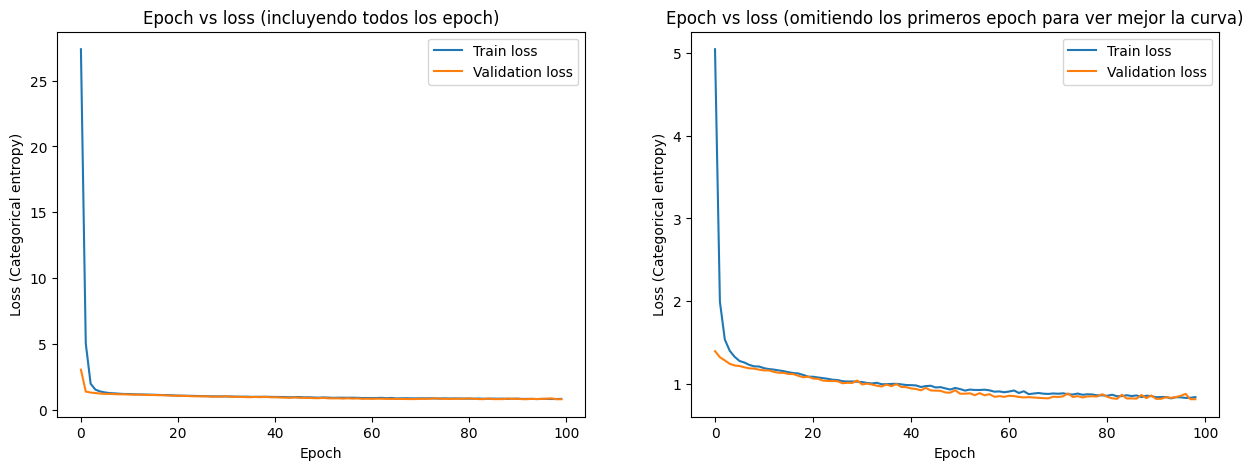

In [10]:
train_loss = train_model.history["loss"]
validation_loss = train_model.history["val_loss"]
train_accuracy = train_model.history["accuracy"]
validation_accuracy = train_model.history["val_accuracy"]

fg, ax = plt.subplots(1,2, figsize=(15, 5))

ax[0].plot(train_loss, label="Train loss")
ax[0].plot(validation_loss, label="Validation loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss (Categorical entropy)")
ax[0].set_title("Epoch vs loss (incluyendo todos los epoch)")
ax[0].legend()

ax[1].plot(train_loss[1:], label="Train loss")
ax[1].plot(validation_loss[1:], label="Validation loss")
ax[1].set_title("Epoch vs loss (omitiendo los primeros epoch para ver mejor la curva)")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss (Categorical entropy)")
ax[1].legend()

plt.show()

Se grafica el accuracy a traves de los epochs

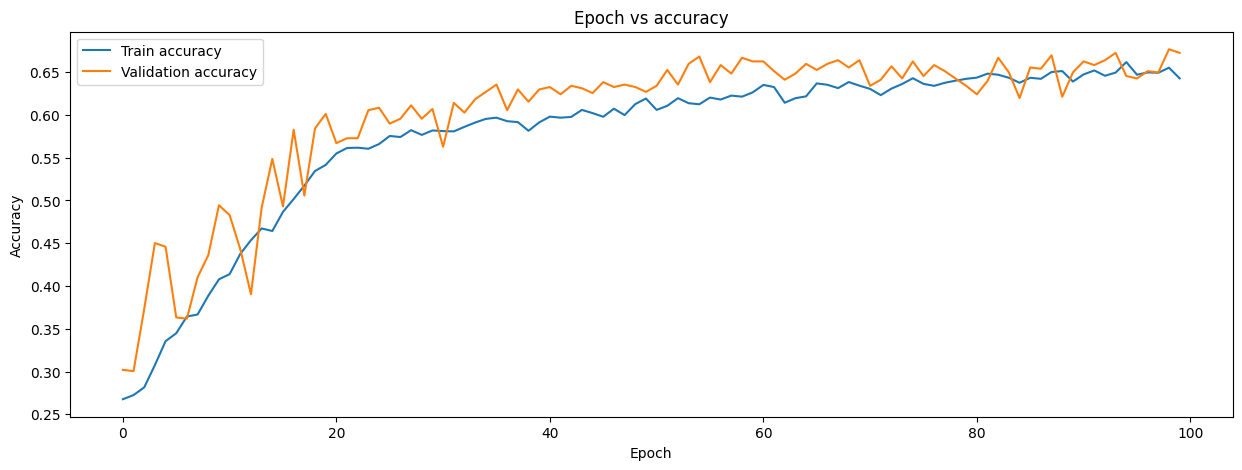

In [11]:
train_accuracy = train_model.history["accuracy"]
validation_accuracy = train_model.history["val_accuracy"]

fg2, ax2 = plt.subplots(figsize=(15, 5))

ax2.plot(train_accuracy, label="Train accuracy")
ax2.plot(validation_accuracy, label="Validation accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Epoch vs accuracy")
ax2.legend()


plt.show()

# Calculo de otras metricas

Para verificar el desempeno de la red neuronal se calculan las siguientes metricas por clase:

1. Accuracy general
2. Precision
3. Sensitivity (Recall)
4. F1 Score
5. AUC ROC

In [12]:
prediction_probability = model.predict(test_data)
prediction = prediction_probability.argmax(axis=1)

result = test_results.argmax(axis=1)

print("Calculo de metricas para el conjunto de test\n")
# Accuracy
acc = sklearn.metrics.accuracy_score(result, prediction)
print(f"ACCURACY")
print(f"Accuracy: {np.round(acc,3)}\n")

# Precision
pre = sklearn.metrics.precision_score(result, prediction, average=None, zero_division=np.nan)
print(f"PRECISION")
print(f"Precision para la clase {dataset.class_names[0]}: {np.round(pre[0],3)}")
print(f"Precision para la clase {dataset.class_names[1]}: {np.round(pre[1],3)}")
print(f"Precision para la clase {dataset.class_names[2]}: {np.round(pre[2],3)}")
print(f"Precision para la clase {dataset.class_names[3]}: {np.round(pre[3],3)}\n")

# Recall (Sensitivity)
sen = sklearn.metrics.recall_score(result, prediction, average=None, zero_division=np.nan)
print(f"SENSITIVITY (RECALL)")
print(f"Sensitivity para la clase {dataset.class_names[0]}: {np.round(sen[0],3)}")
print(f"Sensitivity para la clase {dataset.class_names[1]}: {np.round(sen[1],3)}")
print(f"Sensitivity para la clase {dataset.class_names[2]}: {np.round(sen[2],3)}")
print(f"Sensitivity para la clase {dataset.class_names[3]}: {np.round(sen[3],3)}\n")

# F1-Score
f1_score = sklearn.metrics.f1_score(result, prediction, average=None, zero_division=np.nan)
print(f"F1 SCORE")
print(f"F1 Score para la clase {dataset.class_names[0]}: {np.round(f1_score[0],3)}")
print(f"F1 Score para la clase {dataset.class_names[1]}: {np.round(f1_score[1],3)}")
print(f"F1 Score para la clase {dataset.class_names[2]}: {np.round(f1_score[2],3)}")
print(f"F1 Score para la clase {dataset.class_names[3]}: {np.round(f1_score[3],3)}\n")

# AUC ROC
auc_roc = sklearn.metrics.roc_auc_score(result, prediction_probability, average=None, multi_class="ovr")
print(f"AUC ROC")
print(f"AUC ROC para la clase {dataset.class_names[0]}: {np.round(auc_roc[0],3)}")
print(f"AUC ROC para la clase {dataset.class_names[1]}: {np.round(auc_roc[1],3)}")
print(f"AUC ROC para la clase {dataset.class_names[2]}: {np.round(auc_roc[2],3)}")
print(f"AUC ROC para la clase {dataset.class_names[3]}: {np.round(auc_roc[3],3)}\n")

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Calculo de metricas para el conjunto de test

ACCURACY
Accuracy: 0.683

PRECISION
Precision para la clase glioma: 0.669
Precision para la clase healthy: 0.862
Precision para la clase meningioma: 0.497
Precision para la clase pituitary: 0.721

SENSITIVITY (RECALL)
Sensitivity para la clase glioma: 0.661
Sensitivity para la clase healthy: 0.693
Sensitivity para la clase meningioma: 0.555
Sensitivity para la clase pituitary: 0.811

F1 SCORE
F1 Score para la clase glioma: 0.665
F1 Score para la clase healthy: 0.769
F1 Score para la clase meningioma: 0.524
F1 Score para la clase pituitary: 0.763

AUC ROC
AUC ROC para la clase glioma: 0.899
AUC ROC para la clase healthy: 0.929
AUC ROC para la clase meningioma: 0.781
AUC ROC para la clase pituitary: 0.923



Por ultimo, se grafica la matriz de confusion

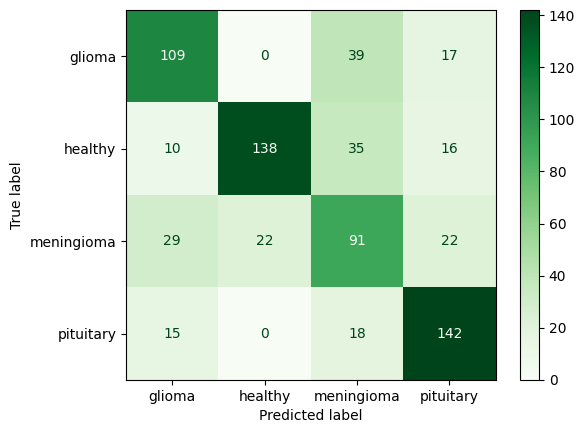

In [13]:
confusion_mat = sklearn.metrics.confusion_matrix(result, prediction)

visualization = sklearn.metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_mat, display_labels=dataset.class_names)

visualization.plot(cmap="Greens")
plt.show()